# Conditioned-MIDI bGPT (Self-Attention Translator) — **midiseq2** model validation

Loads the `Seq2CondMidiPatchy` dataset and the `MidiSeq2BgptSelfAttn` / `MidiSeq2BgptSelfAttnLoss`
model — the **midiseq2** subclass of `MidiBgptTransSelfAttn` (see
`tests/midi/midiBgptTransSelfAttn_validation.ipynb` for the basic-MIDI base). Same prefix-LM idea
(frozen `lyl_encoder` memory scattered into the lilylet-prefix positions of a joint sequence, one HF
`LlamaModel` over `[lyl-prefix ; midi]` under the windowed `[B,1,T,T]` mask), but the midiseq2 data
is **dual-width**:

- joint patches are `patch_size=64` wide; **lilylet** ids sit in columns `[0, lyl_patch_size=16)`
  (`<pad>` tail), **midiseq2** ids (vocab **838**) use the full 64 columns.
- so `lyl_encoder` is built at **width 16** (loads a pretrained 16-wide LilyletNotaGen patch tower
  1:1) and is fed only the first 16 columns, while the midi side / token head run at width 64.

This notebook: inspects a batch, builds the model, verifies **(i)** the dual-width encoder slice
(16 vs 64) and prefix-scatter, **(ii)** the joint mask gates the HF backbone, **(iii)** the new
**per-token-type error** metrics + nan-safe `stat()`, runs a forward pass, overfits one batch,
and checks the pretrained-load / freeze options.

Config: `configs/midi-measurewise-seq2cond.yaml` · Data: `~/data/lilylet/midi-measurewise/test20260629/cond-midiseq2.lmmw.pt`

In [1]:
from pathlib import Path
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel

DATA_DIR = str(Path.home() / 'data')
CONFIG = str(REPO_ROOT / 'configs' / 'midi-measurewise-seq2cond.yaml')
print('repo:', REPO_ROOT)
print('data dir:', DATA_DIR)

repo: /home/camus/work/deep-starry
data dir: /home/camus/data


## 1. Load dataset + a small CPU model, inspect one batch

The corpus is NOT cropped (`max_patches: 0`), so we shrink the model (not the data) to keep this
validation quick on CPU. A 2-sample batch of differing length exercises padding. Note the extra
scalar `lyl_patch_size` the seq2 feeder puts on the batch (the encoder-slice width, read from the
artifact).

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
config['data.batch_size'] = 2
config['trainer.device'] = 'cpu'
# smaller model keeps this validation quick on CPU (data stays uncropped).
# lyl_patch_size (16) and patch_size (64) are the DATA widths — leave them; only shrink capacity.
config['model.args.lyl_hidden_size'] = 64
config['model.args.lyl_patch_num_layers'] = 2
config['model.args.lyl_n_head'] = 4
config['model.args.lyl_num_key_value_heads'] = 4
config['model.args.lyl_intermediate_size'] = 128
config['model.args.d_model'] = 96
config['model.args.n_dec_layer'] = 2
config['model.args.token_num_layers'] = 2
config['model.args.n_head'] = 4
config['model.args.dec_num_key_value_heads'] = 4
config['model.args.num_key_value_heads'] = 4
config['model.args.d_inner'] = 192

train, val = loadDataset(config, data_dir=DATA_DIR, device='cpu')
print('train items:', len(train.dataset), 'val items:', len(val.dataset))

batch = next(iter(train))
print('batch keys:', list(batch.keys()))
for k in ['input_patches', 'input_masks', 'input_targets', 'input_positions', 'attn_mask', 'modality', 'lyl_counts']:
    print(f'  {k:16} {tuple(batch[k].shape)} {batch[k].dtype}')
print('patch width (cols)    :', batch['input_patches'].shape[-1], '(midiseq2 patch_size=64)')
print('lyl_patch_size scalar :', batch['lyl_patch_size'], '(encoder-slice width)')
print('max token id in batch :', int(batch['input_patches'].max()), '(midiseq2 vocab up to 837)')
print('real patches per item :', batch['input_masks'].sum(dim=1).tolist())
print('midi targets per item :', batch['input_targets'].sum(dim=1).tolist())
print('lyl_counts            :', batch['lyl_counts'].tolist())
print('targets only on midi  :', bool(((batch['input_targets'] == 1) & (batch['modality'] == 0)).sum() == 0))

train items: 205 val items: 10
batch keys: ['input_patches', 'input_masks', 'input_targets', 'input_positions', 'attn_mask', 'modality', 'lyl_counts', 'lyl_patch_size']
  input_patches    (2, 711, 64) torch.int64
  input_masks      (2, 711) torch.int64
  input_targets    (2, 711) torch.int64
  input_positions  (2, 711) torch.int64
  attn_mask        (2, 1, 711, 711) torch.bool
  modality         (2, 711) torch.int64
  lyl_counts       (2,) torch.int64
patch width (cols)    : 64 (midiseq2 patch_size=64)
lyl_patch_size scalar : 16 (encoder-slice width)
max token id in batch : 836 (midiseq2 vocab up to 837)
real patches per item : [480, 711]
midi targets per item : [135, 189]
lyl_counts            : [344, 521]
targets only on midi  : True


## 2. Build the model via the factory

`MidiSeq2BgptSelfAttn` subclasses `MidiBgptTransSelfAttn`; the key difference is the **two widths**:
the `lyl_encoder` is a `PatchLevelDecoder` built at `lyl_patch_size` (16) — NOT the midi `patch_size`
(64) — so a pretrained LilyletNotaGen patch tower loads into it, while the midi embedding / token
head run at width 64 over the 838-token midiseq2 vocab.

In [3]:
deducer = loadModel(config['model'], imports=config['imports'])
model = loadModel(config['model'], postfix='Loss', imports=config['imports'])
print('deducer:', type(deducer).__name__, '| loss model:', type(model).__name__)

d = model.deducer
n_params = sum(p.numel() for p in d.parameters())
n_enc = sum(p.numel() for p in d.lyl_encoder.parameters())
print('MidiSeq2BgptSelfAttn params: %.2fM (lyl_encoder %.2fM)' % (n_params / 2**20, n_enc / 2**20))
print('--- two widths ---')
print('  lyl_encoder.patch_size :', d.lyl_encoder.patch_size, '(== lyl_patch_size, 16)')
print('  lyl_patch_size attr    :', d.lyl_patch_size)
print('  midi patch_size        :', d.patch_size, '(64)')
print('  lyl_encoder.patch_embedding in_features:', d.lyl_encoder.patch_embedding.in_features, '(16*256=4096)')
print('  midi_embedding in_features            :', d.midi_embedding.in_features, '(64*838=53632)')
print('joint decoder:', type(d.decoder).__name__, '| self-attn layers:', d.decoder.config.num_hidden_layers)
print('token-level layers:', d.token_level_decoder.base.config.num_hidden_layers,
      '| token vocab:', d.token_level_decoder.base.config.vocab_size)
print('enc_proj (lyl_hidden -> d_model):', tuple(d.enc_proj.weight.shape))
print('lyl/midi vocab:', d.lyl_vocab_size, '/', d.midi_vocab_size)
assert d.lyl_encoder.patch_size == 16 and d.patch_size == 64
assert d.token_level_decoder.base.config.vocab_size == 838

deducer: MidiSeq2BgptSelfAttn | loss model: MidiSeq2BgptSelfAttnLoss
MidiSeq2BgptSelfAttn params: 5.75M (lyl_encoder 0.33M)
--- two widths ---
  lyl_encoder.patch_size : 16 (== lyl_patch_size, 16)
  lyl_patch_size attr    : 16
  midi patch_size        : 64 (64)
  lyl_encoder.patch_embedding in_features: 4096 (16*256=4096)
  midi_embedding in_features            : 53632 (64*838=53632)
joint decoder: LlamaModel | self-attn layers: 2
token-level layers: 2 | token vocab: 838
enc_proj (lyl_hidden -> d_model): (96, 64)
lyl/midi vocab: 256 / 838


## 3. Dual-width encoder slice + prefix-scatter, and the joint mask gates the HF backbone

**(a) dual-width slice + prefix-scatter** — this is the distinctive midiseq2 fix. The encoder is fed
only the **first `lyl_patch_size` (16) columns** of the lilylet patches (`patches[:, :Lmax, :16]`),
NOT the full 64 width the base uses (ids are clamped to the lyl vocab so mixed-length batches, whose
`[lyl_count, Lmax)` rows are midi patches with ids > 256, don't blow up the encoder's one-hot). The
projected memory then fills exactly the lilylet-prefix positions `[0, lyl_count)` of the joint
embedding; midi positions carry the midi embedding.

**(b) mask gating** — blocking a real midi query row in the joint mask changes that row's decoder
hidden state, while an unaffected earlier row is bit-identical — the windowed coupling is actually
enforced by the fused-attention backbone.

In [4]:
m = model.deducer
m.eval()
patches = batch['input_patches'].reshape(len(batch['input_patches']), -1, m.patch_size)  # width 64
B, T, _ = patches.shape
Lmax = int(batch['lyl_counts'].max())

# reproduce the forward's encoder->project->scatter, using the DUAL-WIDTH 16-col slice
lyl_patches = patches[:, :Lmax, :m.lyl_patch_size].clamp(max=m.lyl_vocab_size - 1)  # first 16 cols, ids clamped to lyl vocab
print('lyl encoder input width:', lyl_patches.shape[-1], '(16) vs joint patch width:', patches.shape[-1], '(64)')
lyl_real = ((batch['modality'][:, :Lmax] == 0) & (batch['input_masks'][:, :Lmax] == 1)).long()
lyl_pos = batch['input_positions'][:, :Lmax]
with torch.no_grad():
    memory = m.enc_proj(m.lyl_encoder(lyl_patches, lyl_real, position_ids=lyl_pos)['last_hidden_state'])
    midi_emb = m._midi_embed(patches)
    joint = midi_emb.clone()
    is_lyl = (batch['modality'][:, :Lmax] == 0).unsqueeze(-1)
    joint[:, :Lmax] = torch.where(is_lyl, memory.to(joint.dtype), joint[:, :Lmax])

b = int(batch['lyl_counts'].argmax())    # longest-lyl sample: Lb==Lmax, so [Lb,T) is pure midi (never in the where-overwrite window [0,Lmax))
Lb = int(batch['lyl_counts'][b])
scatter_ok = torch.allclose(joint[b, :Lb], memory[b, :Lb].to(joint.dtype), atol=1e-5)
midi_ok = torch.allclose(joint[b, Lb:T], midi_emb[b, Lb:T], atol=1e-5)
print('(a) encoder consumed the 16-col slice                           :', lyl_patches.shape[-1] == 16)
print('(a) prefix positions [0,lyl_count) hold projected encoder memory :', bool(scatter_ok))
print('(a) midi positions [lyl_count,T) hold the midi embedding         :', bool(midi_ok))

# (b) mask gating
real_midi = ((batch['modality'][b] == 1) & (batch['input_masks'][b] == 1)).nonzero().flatten()
qrow = int(real_midi[-1])
full = batch['attn_mask'].clone()
blocked = full.clone()
blocked[b, 0, qrow, :] = False
blocked[b, 0, qrow, qrow] = True
with torch.no_grad():
    h_full = m.decoder(inputs_embeds=joint, attention_mask=full, position_ids=batch['input_positions'])['last_hidden_state']
    h_blk = m.decoder(inputs_embeds=joint, attention_mask=blocked, position_ids=batch['input_positions'])['last_hidden_state']
row0 = int(real_midi[0])
print('(b) blocked query row hidden changes  :', not torch.allclose(h_full[b, qrow], h_blk[b, qrow], atol=1e-6))
print('(b) earlier row (unaffected) identical:', torch.allclose(h_full[b, row0], h_blk[b, row0], atol=1e-6))
assert scatter_ok and midi_ok and lyl_patches.shape[-1] == 16

lyl encoder input width: 16 (16) vs joint patch width: 64 (64)


(a) encoder consumed the 16-col slice                           : True
(a) prefix positions [0,lyl_count) hold projected encoder memory : True
(a) midi positions [lyl_count,T) hold the midi embedding         : True
(b) blocked query row hidden changes  : True
(b) earlier row (unaffected) identical: True


## 4. Forward pass: loss, per-token-type metrics, inspectRun

The derived Loss reports the base `acc`/`err` (always) plus, in **eval** mode, the
**per-midiseq2-token-type** ERROR rates (`err_type` / `err_elapse` / `err_pitch` / `err_vel` /
`err_channel` / `err_nibble`; `special` & `sep` are omitted), each a `WeightedValue(err, count)` so
cross-batch averaging is nan-safe. Token types are derived from `Midiseq2Tokenizer` (the same vocab
asset the feeder consumes), not hardcoded ids. (`err_type` — the next-token error on event-type
keywords — subsumes the old first-token `type_err`, which was removed as redundant.)

In [5]:
from starry.utils.weightedValue import WeightedValue

# train mode: cheap — only acc/err, no grouped metrics
model.train()
loss, metric_train = model(batch)
print('TRAIN loss:', loss.item(), '| metric keys:', sorted(metric_train.keys()))
assert loss.requires_grad and loss.dim() == 0 and torch.isfinite(loss)
assert not any(isinstance(v, WeightedValue) for v in metric_train.values()), 'grouped metrics must be train-gated'

# eval mode: full metric set incl. grouped WeightedValue per token type
model.eval()
loss_e, metric_eval = model(batch)
print('\nEVAL loss:', loss_e.item())
plain = {k: v for k, v in metric_eval.items() if not isinstance(v, WeightedValue)}
grouped = {k: v for k, v in metric_eval.items() if isinstance(v, WeightedValue)}
print('plain metrics  :', {k: round(v, 4) for k, v in plain.items()})
print('per-token-type error (rate | count):')
for k in sorted(grouped):
    wv = grouped[k]
    print('  %-12s %s  (n=%d)' % (k, ('  --  ' if wv.weight == 0 else '%.4f' % wv.value), wv.weight))
    assert wv.weight == 0 or 0.0 <= wv.value <= 1.0

with torch.no_grad():
    insp = model.inspectRun(batch)
print('\ninspect:', {k: (tuple(v.shape) if torch.is_tensor(v) else v) for k, v in insp.items() if k != 'logits' or True})
assert insp['n_patches'] == sum(batch['input_targets'].sum(dim=1).tolist())
assert insp['logits'].shape[1] == d.patch_size + 1 and insp['logits'].shape[2] == 838

TRAIN loss: 6.692553997039795 | metric keys: ['acc', 'err']



EVAL loss: 6.692580699920654
plain metrics  : {'acc': 0.0005, 'err': 0.9995}
per-token-type error (rate | count):
  err_channel    --    (n=0)
  err_elapse   1.0000  (n=3305)
  err_nibble   1.0000  (n=50)
  err_pitch    0.9986  (n=5022)
  err_type     1.0000  (n=5038)
  err_vel      0.9997  (n=3354)



inspect: {'loss': 6.692580699920654, 'acc': 0.0004687408509198576, 'err': 0.9995312591490801, 'logits': (324, 65, 838), 'target_patches': (324, 64), 'n_patches': 324, 'err_type': 1.0, 'err_elapse': 1.0, 'err_channel': inf, 'err_pitch': 0.9986061330419034, 'err_vel': 0.999701848544646, 'err_nibble': 1.0}


### 4b. `stat()` nan-safe aggregation + single `error/*` panel

The trainer accumulates each metric across batches with `+` then calls `model.stat(data, n_batch)`.
Plain scalars (`acc`/`err`/`loss`) stay top-level and are divided by `n_batch`; every per-token-type
`WeightedValue` group expands to its weighted `.value` and is **folded into a single nested `error`
dict** (`err_` prefix stripped) so the trainer's `reportScalars` renders them as ONE `error/*`
TensorBoard panel — the same grouping convention as `topology.RectifySieveJointer2Loss.stat`'s
`accuracy` dict. A class **absent from the whole epoch** (weight 0) is dropped rather than logged as
`inf`/`nan` (e.g. `channel` — this corpus is always channel 0, which midiseq2 omits).

In [6]:
# emulate the trainer: accumulate two eval batches' metrics, then stat()
def accum(dst, src):
    for k, v in src.items():
        dst[k] = dst[k] + v if k in dst else v
    return dst

acc_data = {}
model.eval()
with torch.no_grad():
    for _ in range(2):
        _, mv = model(batch)
        # the trainer also carries loss; add it as a plain scalar
        mv = {**mv, 'loss': torch.tensor(loss_e.item())}
        accum(acc_data, mv)

stat = model.stat(acc_data, n_batch=2)
print('stat() top-level keys:', sorted(stat.keys()))
import math
# plain scalars stay top-level; per-token-type errors are grouped under the single nested 'error' dict
plain_stat = {k: v for k, v in stat.items() if not isinstance(v, dict)}
error_group = stat.get('error', {})
for k in sorted(plain_stat):
    print('  %-12s %.4f' % (k, float(plain_stat[k])))
print('error/* panel (grouped, err_ prefix stripped):', sorted(error_group.keys()))
for k in sorted(error_group):
    print('  error/%-10s %.4f' % (k, float(error_group[k])))

flat = [float(v) for v in plain_stat.values()] + [float(v) for v in error_group.values()]
assert all(math.isfinite(v) for v in flat), 'stat produced non-finite'
# the per-token-type errors must be grouped, not flat top-level keys
assert isinstance(stat.get('error'), dict) and not any(k.startswith('err_') for k in stat), 'errors must be grouped under error/*'
assert 'type_err' not in stat, 'type_err was removed (redundant with error/type)'
absent = [k for k, v in acc_data.items() if isinstance(v, WeightedValue) and v.weight == 0]
# an absent (weight-0) class is dropped: its stripped name is absent from the error group
absent_stripped = [k[4:] if k.startswith('err_') else k for k in absent]
print('absent (weight-0) classes dropped from error/*:', all(s not in error_group for s in absent_stripped))

stat() top-level keys: ['acc', 'err', 'error', 'loss']
  acc          0.0005
  err          0.9995
  loss         6.6926
error/* panel (grouped, err_ prefix stripped): ['elapse', 'nibble', 'pitch', 'type', 'vel']
  error/elapse     1.0000
  error/nibble     1.0000
  error/pitch      0.9986
  error/type       1.0000
  error/vel        0.9997
absent (weight-0) classes dropped from error/*: True


## 5. Overfit one batch — loss should drop, acc should rise

In [7]:
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
history = []
for step in range(20):
    opt.zero_grad()
    loss, metric = model(batch)
    loss.backward()
    opt.step()
    history.append((loss.item(), metric['acc']))
    if step % 5 == 0 or step == 19:
        print(f'step {step:02d}  loss={loss.item():.4f}  acc={metric["acc"]:.4f}')

print('\nloss start -> end:', round(history[0][0], 4), '->', round(history[-1][0], 4))
print('acc  start -> end:', round(history[0][1], 4), '->', round(history[-1][1], 4))
assert history[-1][0] < history[0][0], 'loss did not decrease'

step 00  loss=6.6926  acc=0.0005


step 05  loss=5.5809  acc=0.4366


step 10  loss=4.7935  acc=0.5351


step 15  loss=4.1460  acc=0.5754


step 19  loss=3.6826  acc=0.5938

loss start -> end: 6.6926 -> 3.6826
acc  start -> end: 0.0005 -> 0.5938


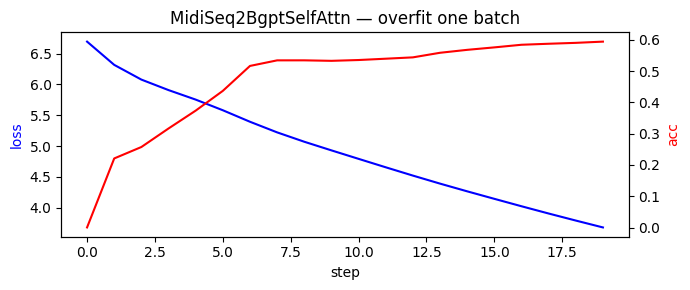

In [8]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

losses = [h[0] for h in history]
accs = [h[1] for h in history]
fig, ax1 = plt.subplots(figsize=(7, 3))
ax1.plot(losses, 'b-', label='loss'); ax1.set_ylabel('loss', color='b'); ax1.set_xlabel('step')
ax2 = ax1.twinx(); ax2.plot(accs, 'r-', label='acc'); ax2.set_ylabel('acc', color='r')
plt.title('MidiSeq2BgptSelfAttn — overfit one batch'); plt.tight_layout(); plt.show()

## 6. Independent towers: pretrained load + freeze

The `lyl_encoder` is a width-**16** `PatchLevelDecoder` (same arch as `LilyletNotaGen.patch_level_decoder`
with `patch_size=16`), so a pretrained NotaGen patch tower loads with **0 missing / 0 unexpected** —
the whole point of the dual-width rebuild (a 64-wide encoder would silently drop the `patch_embedding`).
With `freeze_lyl_encoder=True` the encoder is detached from training: `requires_grad=False`, kept in
`eval()` under `model.train()`, no grads, excluded from `training_parameters()`.

In [9]:
from starry.lilylet.models.notagen import LilyletNotaGen

# (a) key alignment: a real NotaGen patch tower (patch_size=16) -> the width-16 lyl_encoder
nota = LilyletNotaGen(base_type='llama', token_vocab_size=256, patch_size=16, patch_length=1024,
    hidden_size=64, patch_num_layers=2, token_num_layers=2, n_head=4, num_key_value_heads=4, intermediate_size=128)
missing, unexpected = model.deducer.lyl_encoder.load_state_dict(nota.patch_level_decoder.state_dict(), strict=False)
print('pretrained load: missing=%d unexpected=%d' % (len(missing), len(unexpected)))
assert not missing and not unexpected

# (b) freeze: build a frozen variant via the factory and verify it is detached from training
config['model.args.freeze_lyl_encoder'] = True
frozen = loadModel(config['model'], postfix='Loss', imports=config['imports'])
frozen.train()  # frozen encoder must stay in eval
n_total = sum(1 for _ in frozen.parameters())
n_train = len([p for p in frozen.deducer.parameters_trainable() if p.requires_grad])
print('freeze: encoder all requires_grad False:', all(not p.requires_grad for p in frozen.deducer.lyl_encoder.parameters()))
print('freeze: encoder stays eval under train():', not frozen.deducer.lyl_encoder.training)
print('freeze: trainable tensors %d of %d total' % (n_train, n_total))

# parameters_trainable stable under requires_grad_(False) (distributed param-broadcast safety)
n_before = len(frozen.deducer.parameters_trainable())
frozen.requires_grad_(False)
n_after = len(frozen.deducer.parameters_trainable())
print('freeze: parameters_trainable stable under requires_grad_(False): %s (%d==%d)' % (n_before == n_after, n_before, n_after))
frozen = loadModel(config['model'], postfix='Loss', imports=config['imports']); frozen.train()  # fresh (grads restored)

loss_f, _ = frozen(batch); loss_f.backward()
enc_grads = sum(1 for p in frozen.deducer.lyl_encoder.parameters() if p.grad is not None)
dec_grads = sum(1 for p in frozen.deducer.decoder.parameters() if p.grad is not None)
print('freeze: lyl_encoder grad tensors=%d (expect 0), decoder grad tensors=%d (expect >0)' % (enc_grads, dec_grads))
assert enc_grads == 0 and dec_grads > 0
config['model.args.freeze_lyl_encoder'] = False  # restore

pretrained load: missing=0 unexpected=0
freeze: encoder all requires_grad False: True
freeze: encoder stays eval under train(): True
freeze: trainable tensors 45 of 67 total
freeze: parameters_trainable stable under requires_grad_(False): True (45==45)


freeze: lyl_encoder grad tensors=0 (expect 0), decoder grad tensors=19 (expect >0)
